# Target Label Analysis and Filtering

This notebook runs post-union target-label normalization, mapping, analysis, and optional low-group filtering.

## What this notebook does
1. Loads `04_union_primary.tsv` and `04_dedup_primary.tsv` from the union notebook outputs.
2. Parses and logs unique raw target labels for each dataset.
3. Applies an explicit raw-to-standardized target mapping into `target_std`.
4. Reports standardized label breakdowns for all rows and for `binary_hate == 1`.
5. Optionally drops rows for groups with low positive-hate support (`binary_hate == 1` count below threshold).
6. Displays before/after impacts and a pie chart after filtering.

In [17]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import List
import json
import re

import matplotlib.pyplot as plt
import pandas as pd

# Resolve workspace root robustly for notebook execution in multiple contexts.
WORKDIR = Path.cwd()
if not (WORKDIR / 'outputs').exists():
    WORKDIR = Path('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles')

@dataclass
class TargetAnalysisConfig:
    union_input: Path = WORKDIR / 'outputs' / 'preprocessing' / 'union' / '04_union_primary.tsv'
    dedup_input: Path = WORKDIR / 'outputs' / 'preprocessing' / 'union' / '04_dedup_primary.tsv'

    # Optional outputs for filtered datasets.
    filtered_union_output: Path = WORKDIR / 'outputs' / 'preprocessing' / 'union' / '05_union_primary_filtered.tsv'
    filtered_dedup_output: Path = WORKDIR / 'outputs' / 'preprocessing' / 'union' / '05_dedup_primary_filtered.tsv'

cfg = TargetAnalysisConfig()
cfg.filtered_union_output.parent.mkdir(parents=True, exist_ok=True)
cfg

TargetAnalysisConfig(union_input=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/04_union_primary.tsv'), dedup_input=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/04_dedup_primary.tsv'), filtered_union_output=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/05_union_primary_filtered.tsv'), filtered_dedup_output=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/05_dedup_primary_filtered.tsv'))

In [18]:
def normalize_target_token(token) -> str:
    """Normalize one raw label to a stable lowercase token."""
    if token is None:
        return ''
    s = str(token).strip().lower().replace('_', ' ')
    s = re.sub(r'\s+', ' ', s)
    if s in {'', 'none', 'null', 'nan'}:
        return ''
    return s


def parse_targets_generic(value) -> List[str]:
    """Parse mixed target formats (list, list-like string, pipe string, comma string) into list[str]."""
    if value is None:
        return []

    if isinstance(value, (list, tuple, set)):
        candidates = list(value)
    elif isinstance(value, str):
        s = value.strip()
        if not s:
            return []

        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = json.loads(s.replace("'", '"'))
                candidates = parsed if isinstance(parsed, list) else [parsed]
            except Exception:
                candidates = [s]
        elif '|' in s:
            candidates = [x.strip() for x in s.split('|')]
        elif ',' in s:
            candidates = [x.strip() for x in s.split(',')]
        else:
            candidates = [s]
    else:
        try:
            if pd.isna(value):
                return []
        except Exception:
            pass
        candidates = [value]

    out = []
    for candidate in candidates:
        norm = normalize_target_token(candidate)
        if norm:
            out.append(norm)

    return sorted(set(out))


def deduplicate_union(union_df: pd.DataFrame) -> pd.DataFrame:
    """Apply ID-first dedup, then fallback text-key dedup."""
    with_id = union_df[union_df['post_id'].notna() & (union_df['post_id'].astype(str).str.strip() != '')]
    with_id = with_id.drop_duplicates(subset=['post_id'], keep='first')

    without_id = union_df[~union_df.index.isin(with_id.index)]
    without_id = without_id.drop_duplicates(subset=['text_dedup_key'], keep='first')

    dedup_df = pd.concat([with_id, without_id], ignore_index=True)
    dedup_df = dedup_df.drop_duplicates(subset=['text_dedup_key'], keep='first')
    return dedup_df


def label_breakdown(df: pd.DataFrame, label_col: str = 'target_std') -> pd.DataFrame:
    exploded = df[[label_col]].explode(label_col)
    exploded = exploded[exploded[label_col].notna() & (exploded[label_col].astype(str).str.strip() != '')]

    if exploded.empty:
        return pd.DataFrame(columns=['target_std_label', 'count', 'percentage'])

    counts = exploded[label_col].value_counts().rename_axis('target_std_label').reset_index(name='count')
    counts['percentage'] = (counts['count'] / counts['count'].sum() * 100).round(2)
    return counts

In [19]:
# Load union outputs produced by 04_union_and_dedup.ipynb.
if not cfg.union_input.exists():
    raise FileNotFoundError(f'Missing union input: {cfg.union_input}')
if not cfg.dedup_input.exists():
    raise FileNotFoundError(f'Missing dedup input: {cfg.dedup_input}')

union_df = pd.read_csv(cfg.union_input, sep='\t')
dedup_df = pd.read_csv(cfg.dedup_input, sep='\t')

# Keep binary_hate type consistent for filtering and summary logic.
union_df['binary_hate'] = pd.to_numeric(union_df['binary_hate'], errors='coerce').astype('Int64')
dedup_df['binary_hate'] = pd.to_numeric(dedup_df['binary_hate'], errors='coerce').astype('Int64')

print('Loaded union rows:', len(union_df))
print('Loaded dedup rows:', len(dedup_df))

FileNotFoundError: Missing union input: /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/04_union_primary.tsv

In [ ]:
# Explicit canonical mapping into one shared schema.
CANONICAL_TARGET_MAP = {
    # Demographic wording variants
    'white people': 'white',
    'black people': 'black',
    'jewish people': 'jewish',
    'muslim people': 'muslim',
    'gay people': 'gay',
    'lesbian people': 'lesbian',
    'trans people': 'trans',
    'transgender': 'trans',
    'women': 'woman',
    'men': 'man',
    'immigrants': 'immigrant',

    # Common plural/alias normalization
    'latinos': 'latino',
    'mexicans': 'mexican',
    'african americans': 'black',

    # MHS axis labels
    'race other': 'race other',
    'religion other': 'religion other',
    'gender other': 'gender other',
    'sexuality other': 'sexuality other',
    'origin other': 'origin other',
    'disability other': 'disability other',
}


# Log and display unique raw labels by dataset.
raw_rows = []
for dataset_name in sorted(union_df['dataset'].dropna().astype(str).unique()):
    ds_df = union_df[union_df['dataset'] == dataset_name]
    labels = sorted(
        {
            label
            for value in ds_df['targets']
            for label in parse_targets_generic(value)
        }
    )
    for label in labels:
        raw_rows.append({'dataset': dataset_name, 'raw_target_label': label})

raw_labels_df = pd.DataFrame(raw_rows)

print('Unique raw target labels by dataset:')
if raw_labels_df.empty:
    print('No target labels found in union_df.')
else:
    display(raw_labels_df.sort_values(['dataset', 'raw_target_label']).reset_index(drop=True))


# Build and display explicit mapping table.
if raw_labels_df.empty:
    mapping_df = pd.DataFrame(columns=['dataset', 'raw_target_label', 'target_std_label', 'mapping_type'])
else:
    mapping_df = raw_labels_df.copy()
    mapping_df['target_std_label'] = mapping_df['raw_target_label'].apply(lambda x: CANONICAL_TARGET_MAP.get(x, x))
    mapping_df['mapping_type'] = mapping_df['raw_target_label'].apply(lambda x: 'manual' if x in CANONICAL_TARGET_MAP else 'identity')

print('Explicit raw -> standardized mapping used in this run:')
display(mapping_df.sort_values(['dataset', 'raw_target_label']).reset_index(drop=True))


def standardize_targets(value) -> List[str]:
    raw_labels = parse_targets_generic(value)
    std_labels = [CANONICAL_TARGET_MAP.get(label, label) for label in raw_labels]
    return sorted(set(std_labels))


union_df['target_std'] = union_df['targets'].apply(standardize_targets)
dedup_df['target_std'] = dedup_df['targets'].apply(standardize_targets)

overall_breakdown = label_breakdown(union_df, label_col='target_std')
hate_breakdown = label_breakdown(union_df[union_df['binary_hate'] == 1].copy(), label_col='target_std')

print('Standardized target label breakdown in union_df (all rows):')
display(overall_breakdown)

print('Standardized target label breakdown in union_df where binary_hate == 1:')
display(hate_breakdown)

Unique raw target labels by dataset:


,dataset,raw_target_label
0,elsherief,"""they"" (group is not specified)"
1,elsherief,a woman
2,elsherief,aap
3,elsherief,aclu
4,elsherief,activists
...,...,...
649,mhs,unspecific
650,mhs,visually impaired
651,mhs,white
652,mhs,women


Explicit raw -> standardized mapping used in this run:


,dataset,raw_target_label,target_std_label,mapping_type
0,elsherief,"""they"" (group is not specified)","""they"" (group is not specified)",identity
1,elsherief,a woman,a woman,identity
2,elsherief,aap,aap,identity
3,elsherief,aclu,aclu,identity
4,elsherief,activists,activists,identity
...,...,...,...,...
649,mhs,unspecific,unspecific,identity
650,mhs,visually impaired,visually impaired,identity
651,mhs,white,white,identity
652,mhs,women,woman,manual


Standardized target label breakdown in union_df (all rows):


,target_std_label,count,percentage
0,gender,16667,7.98
1,woman,15927,7.62
2,race,14697,7.03
3,origin,9300,4.45
4,sexuality,8972,4.29
...,...,...,...
618,poor white people,1,0.00
619,syrian immigrants,1,0.00
620,stubborn people,1,0.00
621,probably lgbt,1,0.00


Standardized target label breakdown in union_df where binary_hate == 1:


,target_std_label,count,percentage
0,woman,4932,7.60
1,gender,4907,7.57
2,race,3861,5.95
3,sexuality,2597,4.00
4,african,2559,3.95
...,...,...,...
618,poor white people,1,0.00
619,syrian immigrants,1,0.00
620,stubborn people,1,0.00
621,probably lgbt,1,0.00


## Drop Lowest Groups

This section optionally removes examples from low-frequency standardized target groups **after union**.

Important: low-frequency groups are defined using only rows where `binary_hate == 1`.

In [ ]:
# Toggle + threshold (easy to modify)
MIN_GROUP_COUNT = 50
DROP_LOWEST_GROUPS = True

if 'target_std' not in union_df.columns:
    raise ValueError('`target_std` is missing. Run the previous target-standardization cell first.')

# Threshold basis: count only positive-hate rows for each standardized group.
hate_only_for_threshold = union_df[union_df['binary_hate'] == 1].copy()

hate_group_counts = (
    hate_only_for_threshold[['target_std']]
    .explode('target_std')
    .dropna()
)
hate_group_counts = hate_group_counts[hate_group_counts['target_std'].astype(str).str.strip() != '']
hate_group_counts = (
    hate_group_counts['target_std']
    .value_counts()
    .rename_axis('target_std_label')
    .reset_index(name='positive_hate_count')
)

low_groups_df = hate_group_counts[hate_group_counts['positive_hate_count'] < MIN_GROUP_COUNT].copy()
low_groups = set(low_groups_df['target_std_label'].tolist())

print(f'MIN_GROUP_COUNT = {MIN_GROUP_COUNT}')
print(f'DROP_LOWEST_GROUPS = {DROP_LOWEST_GROUPS}')
print('Threshold basis: groups with positive-hate count (binary_hate == 1) below MIN_GROUP_COUNT')
print(f'Low-frequency groups found (by positive-hate count): {len(low_groups)}')
if len(low_groups_df):
    display(low_groups_df.sort_values('positive_hate_count', ascending=True).reset_index(drop=True))
else:
    print('No groups fall below threshold.')


# Apply optional filter after union.
if DROP_LOWEST_GROUPS and low_groups:
    union_after_group_filter = union_df[
        ~union_df['target_std'].apply(
            lambda labels: any(lbl in low_groups for lbl in (labels if isinstance(labels, list) else []))
        )
    ].copy()
else:
    union_after_group_filter = union_df.copy()

dedup_after_group_filter = deduplicate_union(union_after_group_filter)

impact_df = pd.DataFrame([
    {
        'dataset_view': 'union',
        'rows_before': len(union_df),
        'rows_after': len(union_after_group_filter),
    },
    {
        'dataset_view': 'dedup',
        'rows_before': len(dedup_df),
        'rows_after': len(dedup_after_group_filter),
    },
])
impact_df['rows_removed'] = impact_df['rows_before'] - impact_df['rows_after']
impact_df['pct_removed'] = (impact_df['rows_removed'] / impact_df['rows_before'] * 100).round(2)

print('Impact of low-frequency group filter on final datasets:')
display(impact_df)


def std_breakdown(df: pd.DataFrame) -> pd.DataFrame:
    exploded = df[['target_std']].explode('target_std').dropna()
    exploded = exploded[exploded['target_std'].astype(str).str.strip() != '']
    if exploded.empty:
        return pd.DataFrame(columns=['target_std_label', 'count'])
    return (
        exploded['target_std']
        .value_counts()
        .rename_axis('target_std_label')
        .reset_index(name='count')
    )

before_groups = std_breakdown(union_df).rename(columns={'count': 'count_before'})
after_groups = std_breakdown(union_after_group_filter).rename(columns={'count': 'count_after'})
group_impact = (
    before_groups
    .merge(after_groups, on='target_std_label', how='outer')
    .fillna(0)
)
group_impact['count_before'] = group_impact['count_before'].astype(int)
group_impact['count_after'] = group_impact['count_after'].astype(int)
group_impact['removed'] = group_impact['count_before'] - group_impact['count_after']
group_impact = group_impact.sort_values(['removed', 'count_before'], ascending=False).reset_index(drop=True)

print('Standardized group counts before vs after filter:')
display(group_impact)

filtered_union_df = union_after_group_filter
filtered_dedup_df = dedup_after_group_filter

# Save filtered artifacts for downstream usage.
filtered_union_df.to_csv(cfg.filtered_union_output, sep='\t', index=False)
filtered_dedup_df.to_csv(cfg.filtered_dedup_output, sep='\t', index=False)
print('Saved filtered union output to:', cfg.filtered_union_output)
print('Saved filtered dedup output to:', cfg.filtered_dedup_output)

MIN_GROUP_COUNT = 50
DROP_LOWEST_GROUPS = True
Threshold basis: groups with positive-hate count (binary_hate == 1) below MIN_GROUP_COUNT
Low-frequency groups found (by positive-hate count): 540


,target_std_label,positive_hate_count
0,religious conservatives,1
1,illegal people,1
2,semites,1
3,twitter,1
4,irish and polish immigrants,1
...,...,...
535,conservatives,43
536,democrats,44
537,indian,45
538,illegals,46


Impact of low-frequency group filter on final datasets:


,dataset_view,rows_before,rows_after,rows_removed,pct_removed
0,union,66072,64176,1896,2.87
1,dedup,65978,64083,1895,2.87


Standardized group counts before vs after filter:


,target_std_label,count_before,count_after,removed
0,age,1545,1397,148
1,woman,15927,15782,145
2,gender,16667,16531,136
3,disability,1537,1417,120
4,sexuality,8972,8863,109
...,...,...,...,...
618,zionists,1,0,1
619,non-white people,256,256,0
620,whites,238,238,0
621,progressives,86,86,0


Saved filtered union output to: /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/union_primary_filtered.tsv
Saved filtered dedup output to: /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/dedup_primary_filtered.tsv


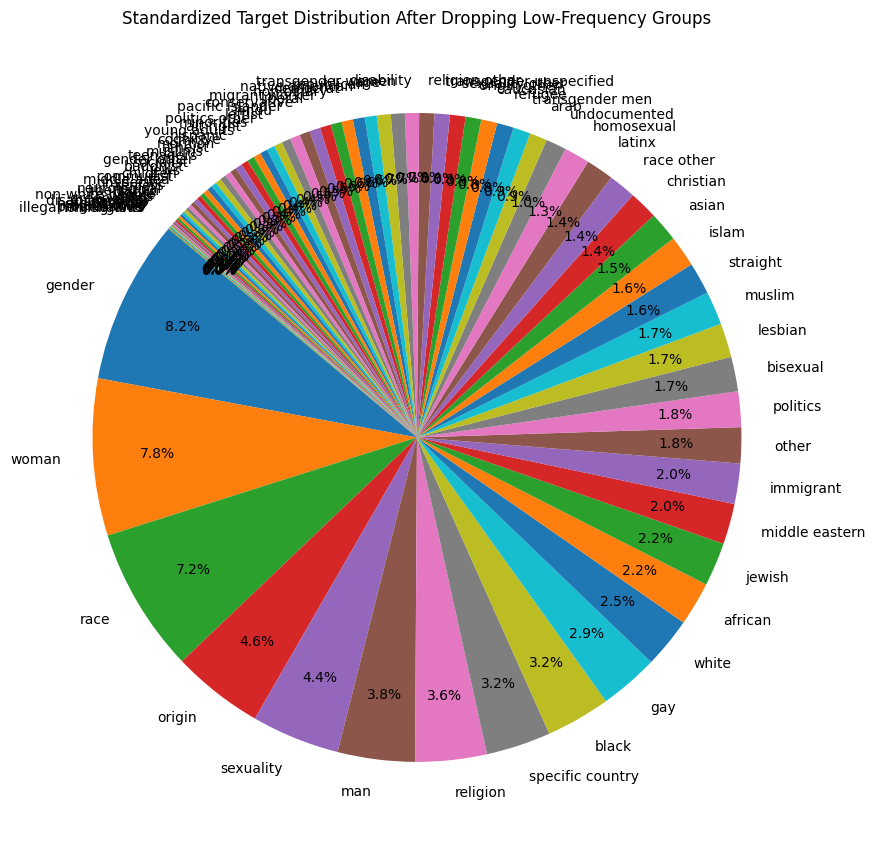

,target_std_label,count_after
0,gender,16531
1,woman,15782
2,race,14592
3,origin,9214
4,sexuality,8863
...,...,...
78,liberals,119
79,black folks,90
80,progressives,86
81,illegal immigrants,82


In [ ]:
# Pie chart: standardized target composition after dropping low-frequency groups.
if 'after_groups' not in globals():
    raise ValueError('`after_groups` not found. Run the previous drop-groups cell first.')

if after_groups.empty:
    print('No standardized target labels available after filtering; pie chart not generated.')
else:
    count_col = 'count_after' if 'count_after' in after_groups.columns else 'count'
    label_col = 'target_std_label' if 'target_std_label' in after_groups.columns else after_groups.columns[0]

    plot_df = after_groups[[label_col, count_col]].copy()
    plot_df = plot_df[plot_df[count_col] > 0]

    if plot_df.empty:
        print('No positive counts available after filtering; pie chart not generated.')
    else:
        plt.figure(figsize=(9, 9))
        plt.pie(
            plot_df[count_col],
            labels=plot_df[label_col],
            autopct='%1.1f%%',
            startangle=140,
            pctdistance=0.8,
        )
        plt.title('Standardized Target Distribution After Dropping Low-Frequency Groups')
        plt.tight_layout()
        plt.show()

        display(plot_df.sort_values(count_col, ascending=False).reset_index(drop=True))

In [ ]:
# Export raw target labels + counts for annotation in Google Sheets.
# Output includes both overall frequency and positive-hate frequency per dataset + raw label.

raw_label_counts_output = WORKDIR / 'outputs' / 'preprocessing' / 'union' / '05_raw_label_counts_for_annotation.tsv'
raw_label_counts_output.parent.mkdir(parents=True, exist_ok=True)


def raw_label_count_table(df: pd.DataFrame, count_col_name: str) -> pd.DataFrame:
    rows = []
    for dataset_name in sorted(df['dataset'].dropna().astype(str).unique()):
        ds_df = df[df['dataset'] == dataset_name]
        for value in ds_df['targets']:
            labels = parse_targets_generic(value)
            for label in labels:
                rows.append({'dataset': dataset_name, 'raw_target_label': label})

    if not rows:
        return pd.DataFrame(columns=['dataset', 'raw_target_label', count_col_name])

    out = (
        pd.DataFrame(rows)
        .value_counts(['dataset', 'raw_target_label'])
        .rename(count_col_name)
        .reset_index()
        .sort_values(['dataset', count_col_name, 'raw_target_label'], ascending=[True, False, True])
        .reset_index(drop=True)
    )
    return out


# Counts over all rows.
raw_counts_all = raw_label_count_table(union_df, count_col_name='count_all_rows')

# Counts over positive-hate rows only.
union_hate_only = union_df[pd.to_numeric(union_df['binary_hate'], errors='coerce') == 1].copy()
raw_counts_hate = raw_label_count_table(union_hate_only, count_col_name='count_binary_hate_1')

# Merge to one annotation-friendly table.
raw_counts_for_annotation = (
    raw_counts_all
    .merge(raw_counts_hate, on=['dataset', 'raw_target_label'], how='outer')
    .fillna(0)
)
raw_counts_for_annotation['count_all_rows'] = raw_counts_for_annotation['count_all_rows'].astype(int)
raw_counts_for_annotation['count_binary_hate_1'] = raw_counts_for_annotation['count_binary_hate_1'].astype(int)

# Optional helper columns for annotation workflow.
raw_counts_for_annotation['target_std_suggested'] = raw_counts_for_annotation['raw_target_label'].apply(
    lambda x: CANONICAL_TARGET_MAP.get(x, x)
)
raw_counts_for_annotation['annotator_notes'] = ''

raw_counts_for_annotation = raw_counts_for_annotation.sort_values(
    ['dataset', 'count_all_rows', 'count_binary_hate_1', 'raw_target_label'],
    ascending=[True, False, False, True],
).reset_index(drop=True)

raw_counts_for_annotation.to_csv(raw_label_counts_output, sep='\t', index=False)

print('Saved raw label count table for annotation to:', raw_label_counts_output)
print('Rows in annotation table:', len(raw_counts_for_annotation))
display(raw_counts_for_annotation.head(25))

Saved raw label count table for annotation to: /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/union/05_raw_label_counts_for_annotation.tsv
Rows in annotation table: 654


,dataset,raw_target_label,count_all_rows,count_binary_hate_1,target_std_suggested,annotator_notes
0,elsherief,immigrants,823,823,immigrant,
1,elsherief,white people,761,761,white,
2,elsherief,minorities,744,744,minorities,
3,elsherief,muslims,604,604,muslims,
4,elsherief,jews,446,446,jews,
5,elsherief,black people,270,270,black,
6,elsherief,blacks,270,270,blacks,
7,elsherief,non-white people,256,256,non-white people,
8,elsherief,whites,238,238,whites,
9,elsherief,liberals,120,120,liberals,
